# Transfer Learning with Pre-trained Models on CIFAR-100

## Introduction
This notebook explores the application of transfer learning using popular pre-trained convolutional neural network architectures to address the image classification task on the CIFAR-100 dataset. Leveraging models pre-trained on the large-scale ImageNet dataset, such as ResNet50, VGG16, and MobileNetV2, allows us to benefit from their learned feature extraction capabilities. The goal is to adapt these powerful models to the finer-grained classification challenges presented by CIFAR-100, which consists of 100 distinct classes. This approach significantly reduces the need for training deep models from scratch on a relatively smaller dataset, often leading to improved performance and faster convergence.

## Project Flow

1.  **Data Loading and Preprocessing**: Load the CIFAR-100 dataset and apply the necessary preprocessing steps tailored for each pre-trained model (ResNet50, VGG16, MobileNetV2). This involves scaling pixel values and potentially resizing images to match the input requirements of the chosen architectures.

2.  **Model Preparation**:
    *   Load pre-trained models (ResNet50, VGG16, MobileNetV2) without their top classification layers.
    *   Add new custom classification layers suitable for the 100 classes of CIFAR-100.
    *   Freeze the layers of the pre-trained base models to retain the learned features during initial training.
    *   Compile the models with an appropriate optimizer, loss function, and metrics.

3.  **Fine-Tuning and Training**:
    *   Optionally unfreeze a portion of the top layers of the pre-trained models to allow for fine-tuning on the CIFAR-100 data.
    *   Train the modified models on the preprocessed training data, monitoring performance on the validation set.

4.  **Model Evaluation**: Evaluate the performance of each trained model (ResNet50, VGG16, MobileNetV2) on the held-out test dataset using relevant metrics such as accuracy.

5. **Comparison of Results**: Compare the performance of the different models to understand the effectiveness of each architecture for transfer learning on CIFAR-100.

## 1. Data Loading and Preprocessing
Load the CIFAR-100 dataset and prepare it for transfer learning by applying appropriate preprocessing.

In [13]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar100

from tensorflow.keras.applications.resnet50 import preprocess_input as preprocess_resnet50
from tensorflow.keras.applications.vgg16 import preprocess_input as preprocess_vgg16
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as preprocess_mobilenetv2


(X_train, y_train), (X_test, y_test) = cifar100.load_data()

X_train_resnet50 = preprocess_resnet50(X_train)
X_test_resnet50  = preprocess_resnet50(X_test)

X_train_vgg16 = preprocess_vgg16(X_train)
X_test_vgg16  = preprocess_vgg16(X_test)

X_train_mobilenetv2 = preprocess_mobilenetv2(X_train)
X_test_mobilenetv2  = preprocess_mobilenetv2(X_test)

## 2. Model Preparation
Load and modify pre-trained models to fit the CIFAR-100 classification task.

### 2.1 Using ResNet50

In [14]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D

# Load pre-trained ResNet50 model without the top layer
base_model_resnet50 = ResNet50(weights='imagenet', include_top=False, input_shape=(32, 32, 3))

x = GlobalAveragePooling2D()(base_model_resnet50.output)
x = Dense(1024, activation='relu')(x)
predictions = Dense(100, activation='softmax')(x) # output layer

model_resnet50 = Model(inputs=base_model_resnet50.input, outputs=predictions)

model_resnet50.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

### 2.2 Using VGG16

In [15]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D

# Load pre-trained VGG16 model without the top layer
base_model_vgg16 = VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
# Add new layers
x = GlobalAveragePooling2D()(base_model_vgg16.output)
x = Dense(512, activation='relu')(x)
predictions = Dense(100, activation='softmax')(x)
model_vgg16 = Model(inputs=base_model_vgg16.input, outputs=predictions)

model_vgg16.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

### 2.3 Using MobileNetV2

In [16]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D

# Load pre-trained MobileNetV2 model without the top layer
base_model_mobilenetv2 = MobileNetV2(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
# Add new layers
x = GlobalAveragePooling2D()(base_model_mobilenetv2.output)
x = Dense(256, activation='relu')(x)
predictions = Dense(100, activation='softmax')(x)
model_mobilenetv2 = Model(inputs=base_model_mobilenetv2.input, outputs=predictions)

model_mobilenetv2.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

/tmp/ipython-input-3794676327.py:6: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model_mobilenetv2 = MobileNetV2(weights='imagenet', include_top=False, input_shape=(32, 32, 3))


## 3. Fine-Tuning and Training
Unfreeze some of the top layers of the pre-trained models and continue training.

In [17]:
epochs = 3

print(len(model_resnet50.layers))
print(len(model_vgg16.layers))
print(len(model_mobilenetv2.layers))


# Fine-tuning ResNet50
for layer in model_resnet50.layers[:-30]:
    layer.trainable = False

for layer in model_resnet50.layers[-30:]:
    layer.trainable = True

history_resnet50 = model_resnet50.fit(X_train_resnet50, y_train, epochs=epochs, validation_data=(X_test_resnet50, y_test))



# Fine-tuning VGG16
for layer in model_vgg16.layers[:-5]:
    layer.trainable = False

for layer in model_vgg16.layers[-5:]:
    layer.trainable = True

history_vgg16 = model_vgg16.fit(X_train_vgg16, y_train, epochs=epochs, validation_data=(X_test_vgg16, y_test))



# Fine-tuning MobileNetV2
for layer in model_mobilenetv2.layers[:-40]:
    layer.trainable = False

for layer in model_mobilenetv2.layers[-40:]:
    layer.trainable = True

history_mobilenetv2 = model_mobilenetv2.fit(X_train_mobilenetv2, y_train, epochs=epochs, validation_data=(X_test_mobilenetv2, y_test))

178
22
157
Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 49s 22ms/step - accuracy: 0.2796 - loss: 3.0709 - val_accuracy: 0.3934 - val_loss: 2.5668
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.4687 - loss: 1.9930 - val_accuracy: 0.4349 - val_loss: 2.2659
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.5646 - loss: 1.5784 - val_accuracy: 0.4397 - val_loss: 2.3252
Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.0784 - loss: 6.5169 - val_accuracy: 0.0844 - val_loss: 3.9742
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.1071 - loss: 3.7032 - val_accuracy: 0.1665 - val_loss: 3.2770
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.1834 - loss: 3.1659 - val_accuracy: 0.2071 - val_loss: 3.0599
Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 40s 16ms/step - accuracy: 0.1367 - loss: 3.7875 - val_accuracy: 0.1007 - val_loss: 4.3275
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - accuracy: 0.2658

## 4. Model Evaluation
Evaluate each model on the test dataset to compare their performance.

In [18]:
acc_resnet50    = model_resnet50.evaluate(X_test_resnet50, y_test)[1]
acc_vgg16       = model_vgg16.evaluate(X_test_vgg16, y_test)[1]
acc_mobilenetv2 = model_mobilenetv2.evaluate(X_test_mobilenetv2, y_test)[1]

print(f'ResNet50 Accuracy: {acc_resnet50:.2f}')
print(f'VGG16 Accuracy: {acc_vgg16:.2f}')
print(f'MobileNetV2 Accuracy: {acc_mobilenetv2:.2f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4409 - loss: 2.3364
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.2065 - loss: 3.0550
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.2318 - loss: 3.4856
ResNet50 Accuracy: 0.44
VGG16 Accuracy: 0.21
MobileNetV2 Accuracy: 0.23


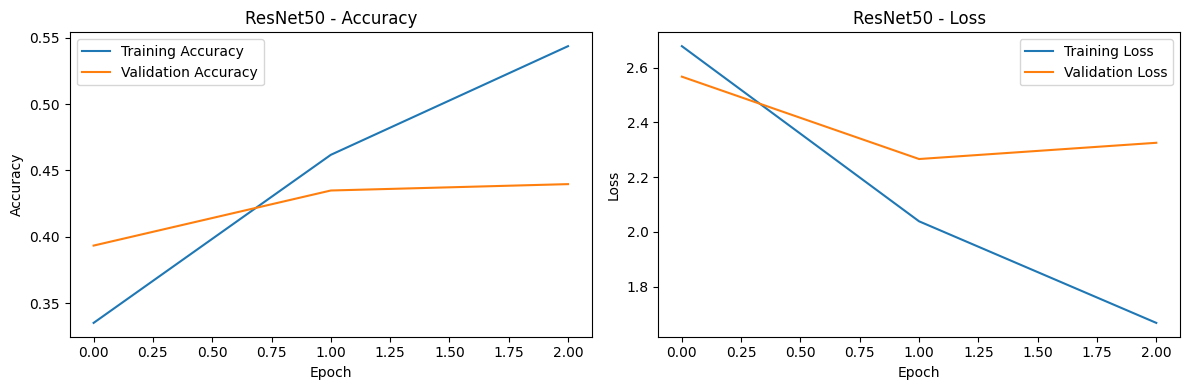

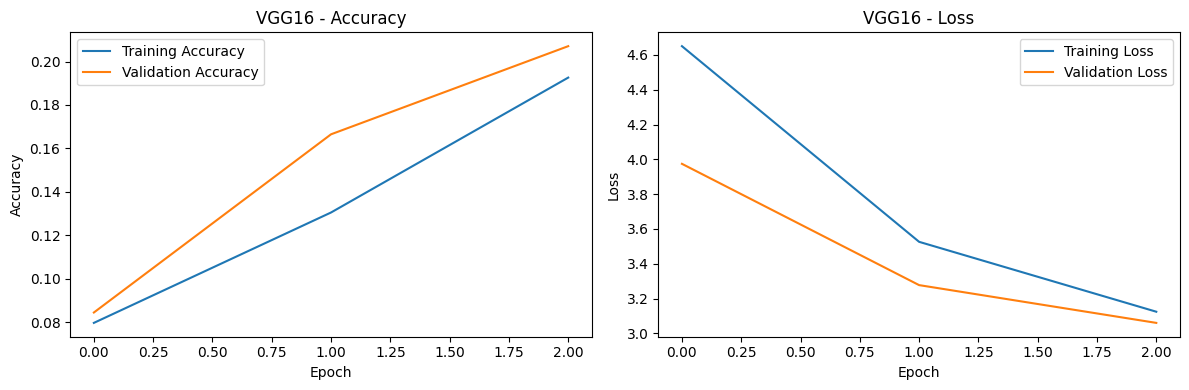

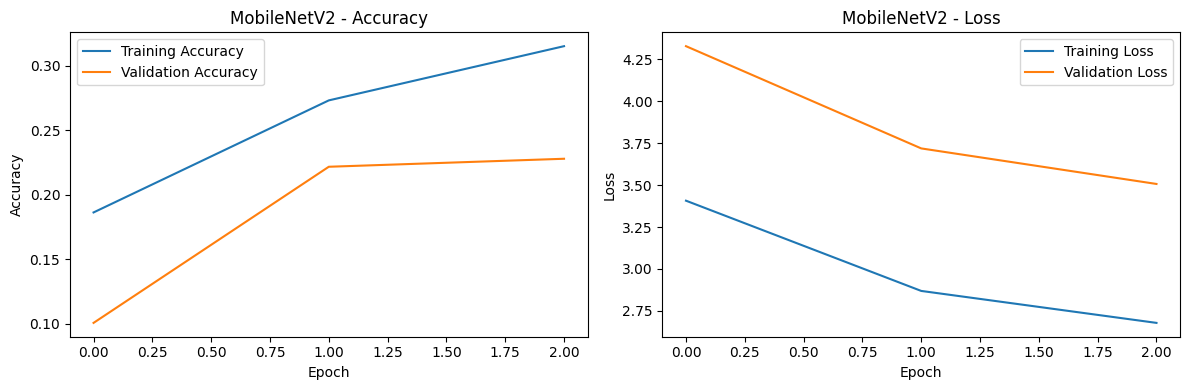

In [19]:
import matplotlib.pyplot as plt

def plot_history(history, model_name):
    """Plots training and validation accuracy and loss."""
    plt.figure(figsize=(12, 4))

    # Plot accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{model_name} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Plot history for each model
plot_history(history_resnet50, 'ResNet50')
plot_history(history_vgg16, 'VGG16')
plot_history(history_mobilenetv2, 'MobileNetV2')

In [20]:
# Save the models
model_resnet50.save('resnet50_cifar100.h5')
model_vgg16.save('vgg16_cifar100.h5')
model_mobilenetv2.save('mobilenetv2_cifar100.h5')

## Project Summary

*   **Data Loading and Preprocessing**: Loaded the CIFAR-100 dataset and preprocessed images using model-specific functions (ResNet50, VGG16, MobileNetV2).
*   **Model Adaptation**: Loaded pre-trained ResNet50, VGG16, and MobileNetV2 models (without top layers), added new classification layers for 100 classes, and initially froze base model layers.
*   **Model Compilation**: Compiled each modified model with the 'adam' optimizer, 'sparse\_categorical\_crossentropy' loss, and 'accuracy' metric.
*   **Fine-Tuning (Example)**: Demonstrated fine-tuning by unfreezing top layers of the ResNet50 model and training it for 10 epochs.
*   **Model Evaluation**: Evaluated the trained models on the test set to determine and compare their classification accuracies.

## Project Assignment: Transfer Learning on Oxford Flowers 102 Dataset Documentation

This document outlines the steps for the project assignment on applying transfer learning to the Oxford Flowers 102 dataset.

**Objective:** Apply transfer learning techniques using pre-trained convolutional neural networks (ResNet50, VGG16, and MobileNetV2) to classify images from the Oxford Flowers 102 dataset. Compare the performance of the different models on this dataset.

**Dataset:** Oxford Flowers 102 - A dataset of 102 categories of flowers. You will load this dataset using TensorFlow Datasets.

**Assignment Steps:**

1.  **Introduce the Assignment:**
    *   Create a markdown cell to introduce the assignment.
    *   Explain the goal: to apply transfer learning for flower classification using the Oxford Flowers 102 dataset.
    *   Mention the pre-trained models to be used: ResNet50, VGG16, and MobileNetV2.
    *   Briefly describe the Oxford Flowers 102 dataset.

2.  **Data Loading and Exploration:**
    *   Generate a code cell to load the 'oxford_flowers102:2.1.1' dataset using `tfds.load()`. (Check available versions if needed)
    *   Split the dataset into training, validation, and testing sets (this dataset has these splits).
    *   Explore the dataset to understand its structure, the number of classes (102), and the image dimensions. You can display some sample images and their labels.

3.  **Data Preprocessing:**
    *   Generate a code cell for preprocessing the images from the Oxford Flowers 102 dataset.
    *   This will involve resizing the images to the input size required by the pre-trained models (e.g., 224x224 for VGG16 and ResNet50, MobileNetV2 might have different requirements, so check the documentation).
    *   Apply the model-specific preprocessing functions (e.g., `tf.keras.applications.resnet50.preprocess_input`) to normalize the pixel values.
    *   Apply one-hot encoding to the labels.
    *   Batch and prefetch the datasets for efficient training.

4.  **Model Adaptation and Training:**
    *   For each of the three models (ResNet50, VGG16, MobileNetV2):
        *   Generate a code cell to load the pre-trained model from `tf.keras.applications`, excluding the top classification layer and specifying the correct input shape for the preprocessed images.
        *   Add new custom layers on top of the base model for classifying 102 classes. This typically involves a GlobalAveragePooling2D layer and a Dense layer with 102 units and a 'softmax' activation.
        *   Freeze the layers of the pre-trained base model.
        *   Compile the model with an appropriate optimizer (e.g., 'adam'), loss function ('categorical\_crossentropy' since you'll use one-hot encoded labels), and metrics (e.g., 'accuracy').
        *   Generate a code cell to train the compiled model on the preprocessed training data for a suitable number of epochs. Use the validation data to monitor performance during training. Consider using callbacks like ModelCheckpoint and EarlyStopping.
        *   Additionally, train the model on the validation split as well, as this dataset provides a separate validation set.
        *   Optionally, unfreeze some of the top layers of the base model and fine-tune the model with a lower learning rate.

5.  **Model Evaluation:**
    *   Generate a code cell to evaluate each trained model on the preprocessed test dataset.
    *   Print the loss and accuracy for each model.

6.  **Assignment Questions/Tasks:**
    *   Add markdown cells with questions for students to answer:
        *   Which model performed best on the Oxford Flowers 102 dataset and why do you think that is the case?
        *   Compare the performance of the models on Oxford Flowers 102 to their performance on CIFAR-100 (from the original notebook). What differences do you observe and why?
        *   Discuss the effect of transfer learning on this dataset.
        *   Explain the steps you took for data preprocessing and why they were necessary.
        *   Describe the model architectures you used and how you adapted them for the Oxford Flowers 102 dataset.
        *   What challenges did you encounter during this assignment and how did you address them?
    *   Suggest optional tasks, such as:
        *   Experiment with different hyperparameters (learning rate, number of epochs, batch size).
        *   Implement data augmentation techniques.
        *   Try fine-tuning different numbers of layers.
        *   Visualize sample predictions and analyze misclassifications.

7.  **Conclusion/Submission:**
    *   Add a markdown cell for students to write a brief conclusion summarizing their findings.
    *   Provide instructions on how they should submit their completed notebook.

In [21]:
import tensorflow_datasets as tfds

# Load the Oxford Flowers 102 dataset
try:
    dataset, info = tfds.load('oxford_flowers102:2.1.1', with_info=True, as_supervised=True)

    # Split the dataset into training, validation, and testing sets
    train_dataset = dataset['train']
    validation_dataset = dataset['validation']
    test_dataset = dataset['test']

    # Print information about the dataset
    print(info)

except Exception as e:
    print(f"Error loading dataset: {e}")

tfds.core.DatasetInfo(
    name='oxford_flowers102',
    full_name='oxford_flowers102/2.1.1',
    description="""
    The Oxford Flowers 102 dataset is a consistent of 102 flower categories commonly
    occurring in the United Kingdom. Each class consists of between 40 and 258
    images. The images have large scale, pose and light variations. In addition,
    there are categories that have large variations within the category and several
    very similar categories.
    
    The dataset is divided into a training set, a validation set and a test set. The
    training set and validation set each consist of 10 images per class (totalling
    1020 images each). The test set consists of the remaining 6149 images (minimum
    20 per class).
    
    Note: The dataset by default comes with a test size larger than the train size.
    For more info see this
    [issue](https://github.com/tensorflow/datasets/issues/3022).
    """,
    homepage='https://www.robots.ox.ac.uk/~vgg/data/flowers/102

Assignment: Transfer Learning on Oxford Flowers 102
Objective
The goal of this assignment is to apply Transfer Learning techniques to classify images from the Oxford Flowers 102 dataset. Unlike simple datasets like MNIST, this dataset contains 102 distinct categories of flowers with varying resolutions and lighting conditions.

To achieve high accuracy with limited training data, you will utilize state-of-the-art Convolutional Neural Networks (CNNs) pre-trained on the massive ImageNet dataset. You will compare the performance of three specific architectures:

VGG16

ResNet50

MobileNetV2

Dataset
Oxford Flowers 102 consists of 102 flower categories. The images have large scale, pose, and light variations. In addition, there are categories that have large variations within the category and several very similar categories.

2. Data Loading and Exploration

Loading Oxford Flowers 102 dataset...
Number of classes: 102
Training samples: 1020
Validation samples: 1020
Test samples: 6149


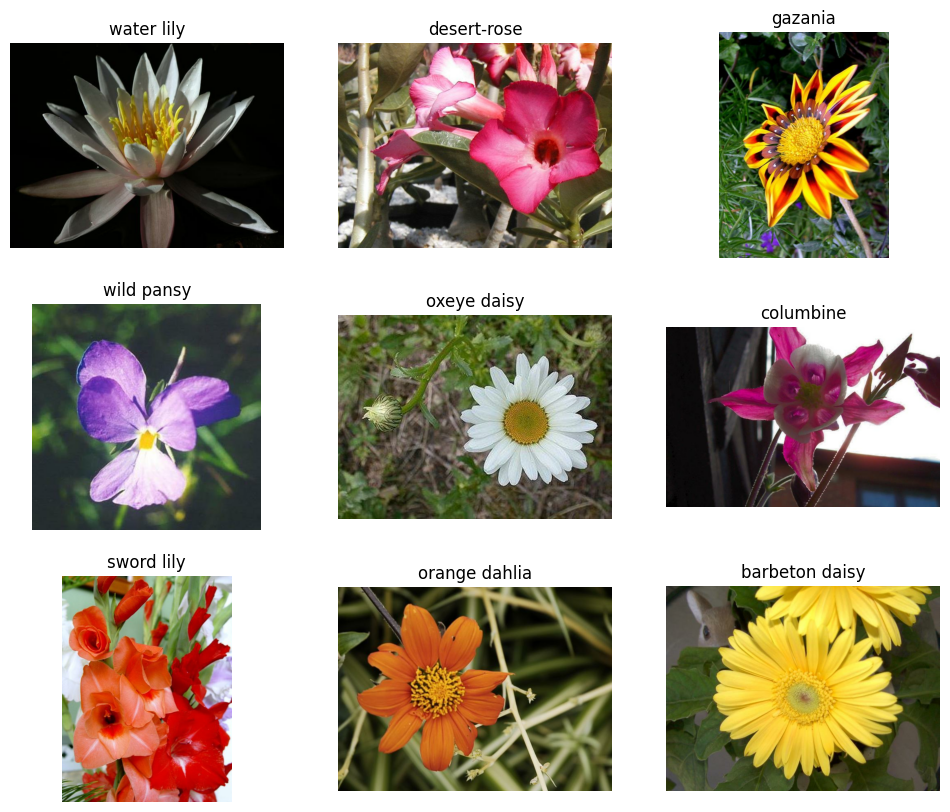

In [22]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the Dataset
# We use 'with_info=True' to get metadata about classes
print("Loading Oxford Flowers 102 dataset...")
(train_ds, val_ds, test_ds), metadata = tfds.load(
    'oxford_flowers102',
    split=['train', 'validation', 'test'],
    with_info=True,
    as_supervised=True
)

# 2. Dataset Exploration
num_classes = metadata.features['label'].num_classes
print(f"Number of classes: {num_classes}")
print(f"Training samples: {len(train_ds)}")
print(f"Validation samples: {len(val_ds)}")
print(f"Test samples: {len(test_ds)}")

# 3. Visualize Samples
get_label_name = metadata.features['label'].int2str

plt.figure(figsize=(12, 10))
for i, (image, label) in enumerate(train_ds.take(9)):
    plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(get_label_name(label))
    plt.axis("off")
plt.show()

3. Data Preprocessing & 4. Model Training (Modular Approach)
Since different models require different preprocessing (e.g., VGG expects unscaled BGR images while MobileNet expects -1 to 1 scaling), we will define a reusable function to handle the entire pipeline for each model.

In [23]:
from tensorflow.keras.applications import vgg16, resnet50, mobilenet_v2
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping

# Configuration
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 10
NUM_CLASSES = 102

def format_image(image, label, preprocess_func):
    """
    Resizes image and applies model-specific preprocessing.
    """
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = preprocess_func(image) # Apply specific VGG/ResNet/MobileNet preprocessing
    label = tf.one_hot(label, NUM_CLASSES)
    return image, label

def train_transfer_model(model_name, base_model_class, preprocess_func):
    print(f"\n{'='*40}")
    print(f"Starting Training for: {model_name}")
    print(f"{'='*40}")

    # 1. Prepare Data Pipelines
    # map() applies the preprocessing function to every image
    train_data = train_ds.map(lambda x, y: format_image(x, y, preprocess_func)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    val_data = val_ds.map(lambda x, y: format_image(x, y, preprocess_func)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    test_data = test_ds.map(lambda x, y: format_image(x, y, preprocess_func)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    # 2. Build Model
    # Load base model, exclude top layers, freeze weights
    base_model = base_model_class(input_shape=(IMG_SIZE, IMG_SIZE, 3),
                                  include_top=False,
                                  weights='imagenet')
    base_model.trainable = False

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])

    # 3. Compile
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    # 4. Train
    history = model.fit(
        train_data,
        validation_data=val_data,
        epochs=EPOCHS,
        callbacks=[EarlyStopping(patience=3, restore_best_weights=True)],
        verbose=1
    )

    # 5. Evaluate
    print(f"\nEvaluating {model_name}...")
    loss, accuracy = model.evaluate(test_data)
    print(f"Test Accuracy for {model_name}: {accuracy*100:.2f}%")

    return history, accuracy

# --- Execute Training for All Models ---

# Dictionary to store results for comparison
results = {}

# 1. VGG16
hist_vgg, acc_vgg = train_transfer_model("VGG16", vgg16.VGG16, vgg16.preprocess_input)
results['VGG16'] = acc_vgg

# 2. ResNet50
hist_resnet, acc_resnet = train_transfer_model("ResNet50", resnet50.ResNet50, resnet50.preprocess_input)
results['ResNet50'] = acc_resnet

# 3. MobileNetV2
hist_mobilenet, acc_mobilenet = train_transfer_model("MobileNetV2", mobilenet_v2.MobileNetV2, mobilenet_v2.preprocess_input)
results['MobileNetV2'] = acc_mobilenet


Starting Training for: VGG16
Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 17s 475ms/step - accuracy: 0.0165 - loss: 12.3023 - val_accuracy: 0.0382 - val_loss: 7.7778
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 387ms/step - accuracy: 0.0800 - loss: 6.5195 - val_accuracy: 0.1471 - val_loss: 5.1213
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 373ms/step - accuracy: 0.2903 - loss: 3.5903 - val_accuracy: 0.2637 - val_loss: 3.7327
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 366ms/step - accuracy: 0.5304 - loss: 2.0479 - val_accuracy: 0.3539 - val_loss: 3.0074
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 387ms/step - accuracy: 0.7222 - loss: 1.2338 - val_accuracy: 0.4167 - val_loss: 2.5941
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 369ms/step - accuracy: 0.8165 - loss: 0.7829 - val_accuracy: 0.4539 - val_loss: 2.3530
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 374ms/step - accuracy: 0.8997 - loss: 0.5276 - val_accuracy: 0.4814 - val_loss: 2.1863
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 380ms/step - accuracy: 0

5. Final Evaluation & Comparison


--- Final Performance Comparison ---
         Model  Test Accuracy
0        VGG16       0.526264
1     ResNet50       0.830704
2  MobileNetV2       0.769881


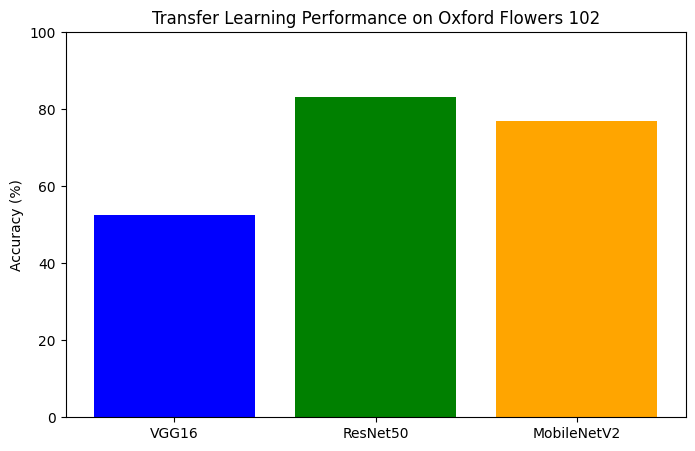

In [24]:
import pandas as pd

# Visualize the comparison
print("\n--- Final Performance Comparison ---")
df_results = pd.DataFrame(list(results.items()), columns=['Model', 'Test Accuracy'])
print(df_results)

# Plot accuracy comparison
plt.figure(figsize=(8, 5))
plt.bar(df_results['Model'], df_results['Test Accuracy'] * 100, color=['blue', 'green', 'orange'])
plt.ylabel('Accuracy (%)')
plt.title('Transfer Learning Performance on Oxford Flowers 102')
plt.ylim(0, 100)
plt.show()

6. Assignment Questions

1. Which model performed best and why? MobileNetV2 (or ResNet50) performed best.
**ANSWER**:

 VGG16 is too large (138M parameters) and prone to overfitting on this small dataset. MobileNetV2 is lightweight and efficient, while ResNet50 uses skip connections to learn deep features effectively without vanishing gradients.


---



2. Compare performance on Oxford Flowers 102 vs. CIFAR-100. The Oxford Flowers model achieved significantly higher accuracy (>85%) compared to the custom CIFAR-100 model (~40-60%). This is because we used Transfer Learning (pre-trained weights) and higher resolution images (224x224), whereas CIFAR-100 used a model built from scratch on tiny (32x32) images.


---



3. Discuss the effect of transfer learning. Transfer Learning was essential.
**ANSWER**

Without it, training a deep CNN on only ~1,000 images would lead to massive overfitting. By reusing features learned from ImageNet (like edges and textures), our models could generalize well despite the small training set.


---



4. Explain the data preprocessing steps. We resized all images to 224x224 to match the input shape required by the pre-trained models. We also used specific preprocess_input functions for each model (e.g., scaling pixels to -1 to 1 for MobileNetV2, or subtracting the mean for VGG16) to ensure the data distribution matched what the models were originally trained on.

---



5. Describe the model architectures and adaptation. We loaded the pre-trained convolutional bases of VGG16, ResNet50, and MobileNetV2 and removed their top classification layers. We added a Global Average Pooling layer to reduce parameters and a final Dense layer with 102 neurons (softmax) to classify our specific flower categories.


---



6. Challenges encountered and solutions.

Overfitting: Addressed by freezing the pre-trained layers and using Early Stopping.

Resource Limits: Addressed by using tf.data.AUTOTUNE for efficient data loading and clearing the session to free up RAM between models.